<b>Model Developed by </b><br>
Name: <b>Umair Ali</b> <br>
Email: <b>uape00@gmail.com</b><br>
GitHub: <b> https://github.com/1umairali/models</b>

Developed a machine learning-based system for detecting brain tumors from MRI images. The project involved preprocessing image data and extracting relevant features, followed by training and evaluating various machine learning classifiers, including Support Vector Classifier (SVC), Logistic Regression, k-Nearest Neighbors (k-NN), Naives Regression, Random Forest, and Decision Tree. The models were assessed based on accuracy and performance metrics to determine the most effective approach for tumor classification. Demonstrated strong skills in medical image analysis and classical machine learning techniques using Python and scikit-learn.

In [1]:
import numpy as np  # for numeric calculation
import pandas as pd  # for data analysis and manupulation
import matplotlib.pyplot as plt  # for data visualization
import seaborn as sns  # for data visualization

In [2]:
# import dataframe
url = 'https://raw.githubusercontent.com/1umairali/models/main/brain_tumor_detection/brain_dataset.csv'
brain_dataframe = pd.read_csv(url)
brain_dataframe

,Image,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,Image1,0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939,7.458341e-155
1,Image2,0,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834,7.458341e-155
2,Image3,1,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014,7.458341e-155
3,Image4,1,5.958145,959.711985,30.979219,0.001477,5.677977,33.428845,151.229741,0.032024,0.001026,0.243851,7.700919,0.964189,7.458341e-155
4,Image5,0,7.315231,729.540579,27.010009,0.146761,4.283221,19.079108,174.988756,0.343849,0.118232,0.501140,6.834689,0.972789,7.458341e-155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3757,Image3758,0,21.234512,1208.850174,34.768523,0.063774,2.082079,4.647310,158.437600,0.220666,0.048693,0.487131,5.211739,0.950972,7.458341e-155
3758,Image3759,0,20.435349,1227.151440,35.030721,0.066763,2.144625,4.882034,161.158675,0.225931,0.051045,0.502712,5.083126,0.952749,7.458341e-155
3759,Image3760,0,18.011520,1151.582765,33.934978,0.068396,2.308349,5.579498,167.130118,0.228930,0.052409,0.492269,5.103700,0.952181,7.458341e-155
3760,Image3761,0,13.330429,945.732779,30.752769,0.087872,2.732822,7.757570,223.812932,0.261527,0.068397,0.480064,6.439784,0.940898,7.458341e-155


In [3]:
# Head (first six rows) of brain dataframe
brain_dataframe.head(6)

,Image,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,Image1,0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939,7.458341e-155
1,Image2,0,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834,7.458341e-155
2,Image3,1,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014,7.458341e-155
3,Image4,1,5.958145,959.711985,30.979219,0.001477,5.677977,33.428845,151.229741,0.032024,0.001026,0.243851,7.700919,0.964189,7.458341e-155
4,Image5,0,7.315231,729.540579,27.010009,0.146761,4.283221,19.079108,174.988756,0.343849,0.118232,0.501140,6.834689,0.972789,7.458341e-155
5,Image6,0,7.524109,607.395258,24.645390,0.214086,3.729886,14.471736,105.077882,0.421587,0.177736,0.598169,4.193146,0.976485,7.458341e-155


In [4]:
# Tail (last six rows) of brain dataframe
brain_dataframe.tail(6)

,Image,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
3756,Image3757,0,20.976822,1144.456066,33.829810,0.062252,2.106235,4.798339,166.395916,0.217934,0.047495,0.488449,5.193088,0.948808,7.458341e-155
3757,Image3758,0,21.234512,1208.850174,34.768523,0.063774,2.082079,4.647310,158.437600,0.220666,0.048693,0.487131,5.211739,0.950972,7.458341e-155
3758,Image3759,0,20.435349,1227.151440,35.030721,0.066763,2.144625,4.882034,161.158675,0.225931,0.051045,0.502712,5.083126,0.952749,7.458341e-155
3759,Image3760,0,18.011520,1151.582765,33.934978,0.068396,2.308349,5.579498,167.130118,0.228930,0.052409,0.492269,5.103700,0.952181,7.458341e-155
3760,Image3761,0,13.330429,945.732779,30.752769,0.087872,2.732822,7.757570,223.812932,0.261527,0.068397,0.480064,6.439784,0.940898,7.458341e-155
3761,Image3762,0,6.110138,480.884025,21.929068,0.118171,4.110669,17.538826,239.251388,0.306224,0.093773,0.494333,6.787329,0.938731,7.458341e-155


In [5]:
# Information of brain dataframe
brain_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Image               3762 non-null   object 
 1   Class               3762 non-null   int64  
 2   Mean                3762 non-null   float64
 3   Variance            3762 non-null   float64
 4   Standard Deviation  3762 non-null   float64
 5   Entropy             3762 non-null   float64
 6   Skewness            3762 non-null   float64
 7   Kurtosis            3762 non-null   float64
 8   Contrast            3762 non-null   float64
 9   Energy              3762 non-null   float64
 10  ASM                 3762 non-null   float64
 11  Homogeneity         3762 non-null   float64
 12  Dissimilarity       3762 non-null   float64
 13  Correlation         3762 non-null   float64
 14  Coarseness          3762 non-null   float64
dtypes: float64(13), int64(1), object(1)
memory usage: 441.0

In [6]:
# show image columns
print(brain_dataframe['Image'])

0          Image1
1          Image2
2          Image3
3          Image4
4          Image5
          ...    
3757    Image3758
3758    Image3759
3759    Image3760
3760    Image3761
3761    Image3762
Name: Image, Length: 3762, dtype: object


image column is object dtype. contains only images name. if we drop that column it will not impact dataframe or result

In [7]:
# drop Image column.
brain_df2 = brain_dataframe.drop(['Image'], axis = 1)
brain_df2

,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939,7.458341e-155
1,0,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834,7.458341e-155
2,1,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014,7.458341e-155
3,1,5.958145,959.711985,30.979219,0.001477,5.677977,33.428845,151.229741,0.032024,0.001026,0.243851,7.700919,0.964189,7.458341e-155
4,0,7.315231,729.540579,27.010009,0.146761,4.283221,19.079108,174.988756,0.343849,0.118232,0.501140,6.834689,0.972789,7.458341e-155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3757,0,21.234512,1208.850174,34.768523,0.063774,2.082079,4.647310,158.437600,0.220666,0.048693,0.487131,5.211739,0.950972,7.458341e-155
3758,0,20.435349,1227.151440,35.030721,0.066763,2.144625,4.882034,161.158675,0.225931,0.051045,0.502712,5.083126,0.952749,7.458341e-155
3759,0,18.011520,1151.582765,33.934978,0.068396,2.308349,5.579498,167.130118,0.228930,0.052409,0.492269,5.103700,0.952181,7.458341e-155
3760,0,13.330429,945.732779,30.752769,0.087872,2.732822,7.757570,223.812932,0.261527,0.068397,0.480064,6.439784,0.940898,7.458341e-155


In [8]:
# Numerical distribution of data
brain_df2.describe()

,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
count,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3762.000000,3.762000e+03
mean,0.447368,9.488890,711.101063,25.182271,0.073603,4.102727,24.389071,127.961459,0.204705,0.058632,0.479252,4.698498,0.955767,7.458341e-155
std,0.497288,5.728022,467.466896,8.773526,0.070269,2.560940,56.434747,109.499601,0.129352,0.058300,0.127929,1.850173,0.026157,0.000000e+00
min,0.000000,0.078659,3.145628,1.773592,0.000882,1.886014,3.942402,3.194733,0.024731,0.000612,0.105490,0.681121,0.549426,7.458341e-155
25%,0.000000,4.982395,363.225459,19.058475,0.006856,2.620203,7.252852,72.125208,0.069617,0.004847,0.364973,3.412363,0.947138,7.458341e-155
50%,0.000000,8.477531,622.580417,24.951560,0.066628,3.422210,12.359088,106.737418,0.225496,0.050849,0.512551,4.482404,0.961610,7.458341e-155
75%,1.000000,13.212723,966.954319,31.095889,0.113284,4.651737,22.640304,161.059006,0.298901,0.089342,0.575557,5.723821,0.971355,7.458341e-155
max,1.000000,33.239975,2910.581879,53.949809,0.394539,36.931294,1371.640060,3382.574163,0.589682,0.347725,0.810921,27.827751,0.989972,7.458341e-155


In [9]:
# check sum of null values in each columns
brain_df2.isnull().sum()

Class                 0
Mean                  0
Variance              0
Standard Deviation    0
Entropy               0
Skewness              0
Kurtosis              0
Contrast              0
Energy                0
ASM                   0
Homogeneity           0
Dissimilarity         0
Correlation           0
Coarseness            0
dtype: int64

## Data Visualization

C:\Users\Umair Ali\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Umair Ali\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Umair Ali\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Umair Ali\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN 

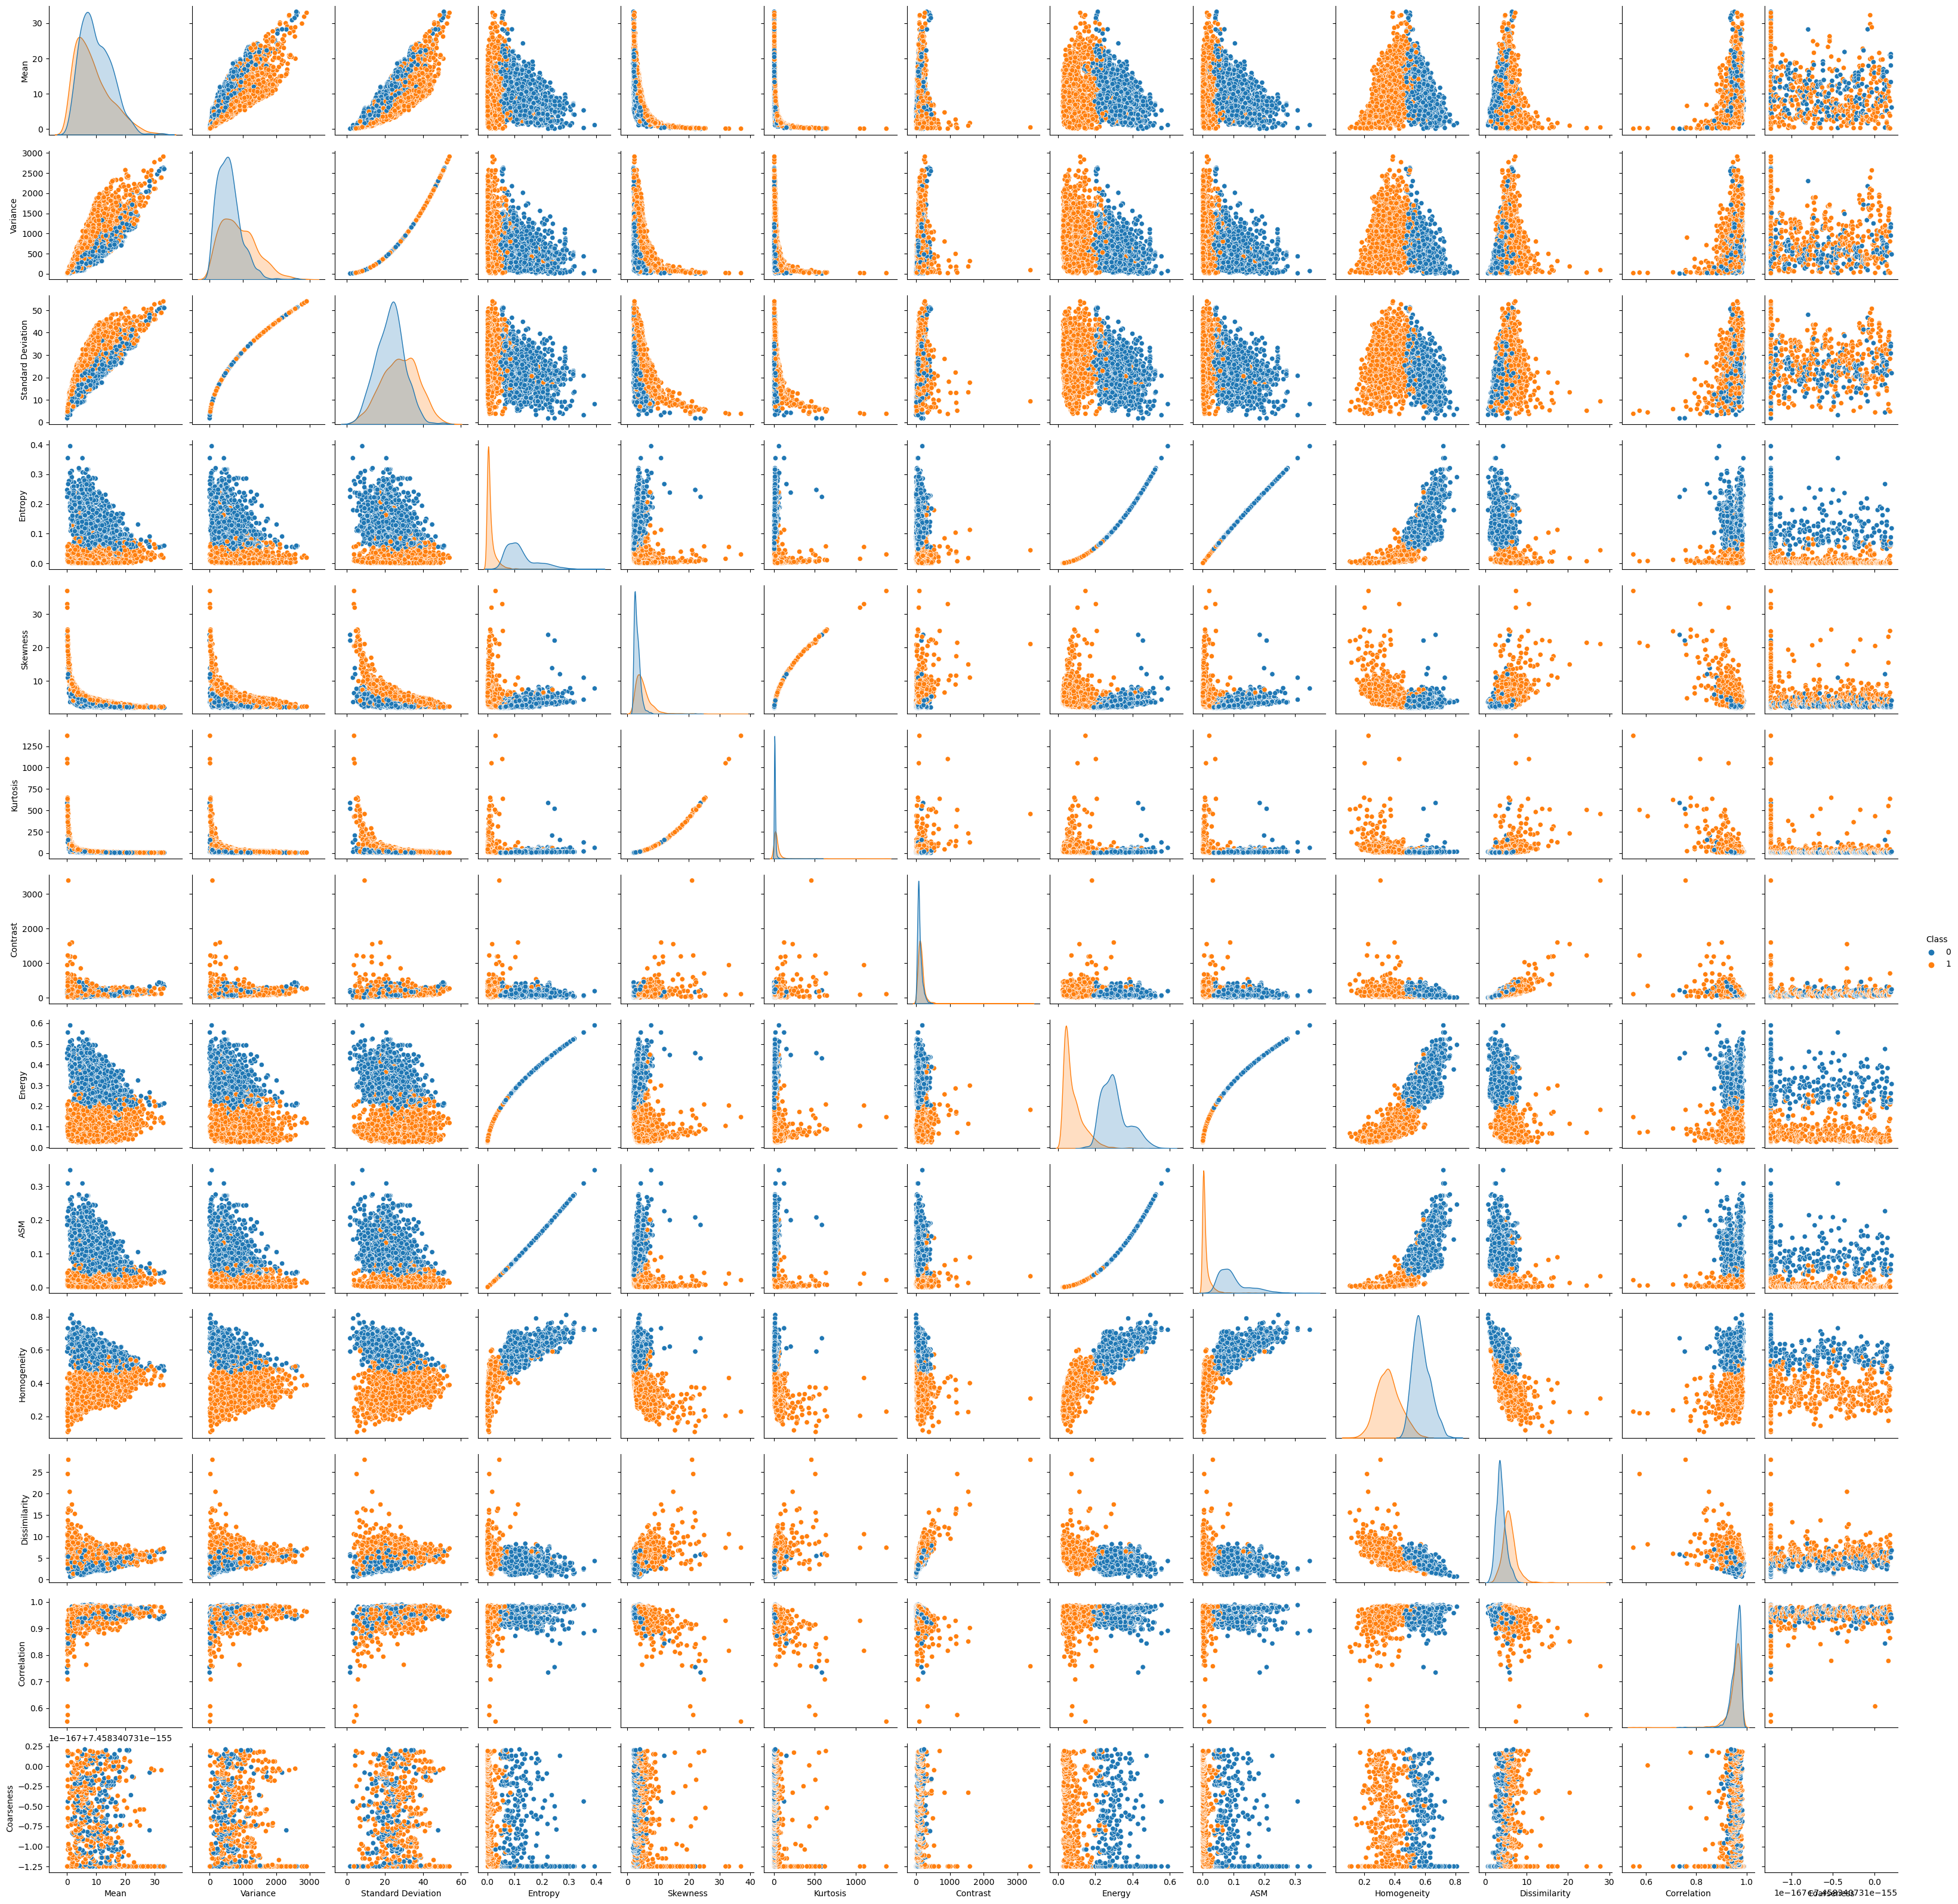

In [10]:
# Pairplot of brain dataframe
sns.pairplot(brain_df2, hue = 'Class')

<Axes: xlabel='Class', ylabel='count'>

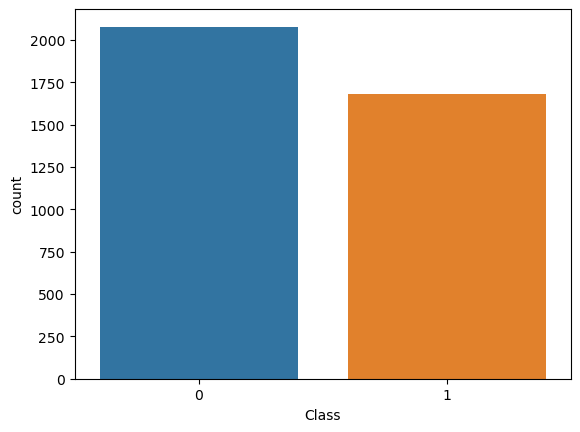

In [11]:
# Count the class columns
# 0 = Non tumor / no cancer
# 1 = Tumor / has cancer
sns.countplot(x=brain_df2["Class"])

## Heatmap

<Axes: >

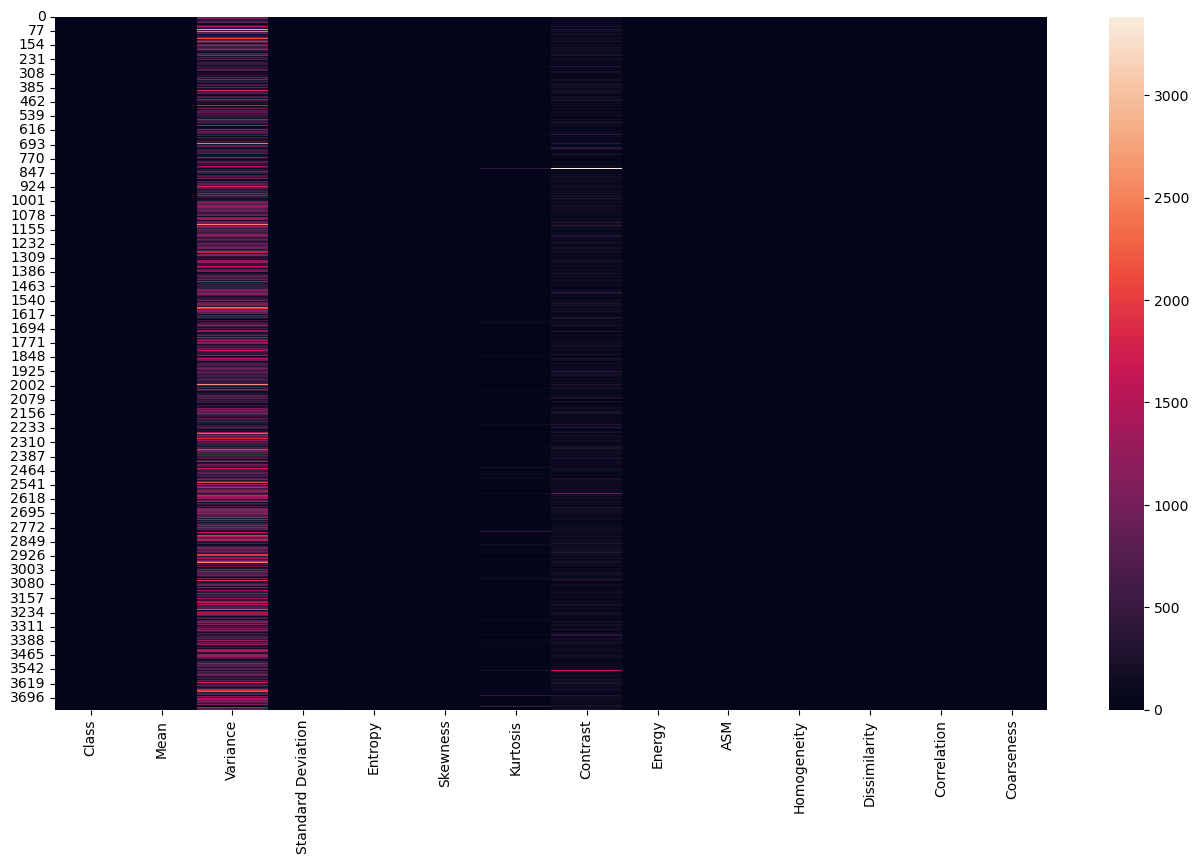

In [12]:
# heatmap of DataFrame
plt.figure(figsize=(16,9))
sns.heatmap(brain_df2)

## Heatmap of a correlation Matrix

In [13]:
# correlation matrix
brain_df2.corr()

,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
Class,1.000000,-0.095729,0.308818,0.285568,-0.778180,0.402644,0.239844,0.212643,-0.862413,-0.758255,-0.847529,0.556319,-0.108601,NaN
Mean,-0.095729,1.000000,0.783027,0.790984,-0.099729,-0.601593,-0.358163,-0.050974,-0.014863,-0.109393,0.095556,-0.113864,0.293693,NaN
Variance,0.308818,0.783027,1.000000,0.975699,-0.344432,-0.347399,-0.248312,0.135494,-0.335470,-0.341061,-0.290527,0.235487,0.288037,NaN
Standard Deviation,0.285568,0.790984,0.975699,1.000000,-0.345127,-0.425428,-0.329798,0.117981,-0.331103,-0.342530,-0.288801,0.224773,0.354161,NaN
Entropy,-0.778180,-0.099729,-0.344432,-0.345127,1.000000,-0.222222,-0.140125,-0.140769,0.971260,0.999213,0.852019,-0.502363,0.122080,NaN
Skewness,0.402644,-0.601593,-0.347399,-0.425428,-0.222222,1.000000,0.899713,0.349856,-0.295413,-0.209289,-0.470054,0.511931,-0.570919,NaN
Kurtosis,0.239844,-0.358163,-0.248312,-0.329798,-0.140125,0.899713,1.000000,0.296664,-0.172454,-0.133741,-0.307314,0.375939,-0.589211,NaN
Contrast,0.212643,-0.050974,0.135494,0.117981,-0.140769,0.349856,0.296664,1.000000,-0.130708,-0.139276,-0.270119,0.761497,-0.427443,NaN
Energy,-0.862413,-0.014863,-0.335470,-0.331103,0.971260,-0.295413,-0.172454,-0.130708,1.000000,0.961628,0.915988,-0.545774,0.123680,NaN
ASM,-0.758255,-0.109393,-0.341061,-0.342530,0.999213,-0.209289,-0.133741,-0.139276,0.961628,1.000000,0.837139,-0.491813,0.121054,NaN


we checked in information 'Coarseness' column is float datatype. contains 0 values which is not empty.......
but in corelation matrix it contain NaN values......
we have to remove that column. it will not impact the result......
lets confirm in Heatmap and Barplot of Correlation Matrix

C:\Users\Umair Ali\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


<Axes: >

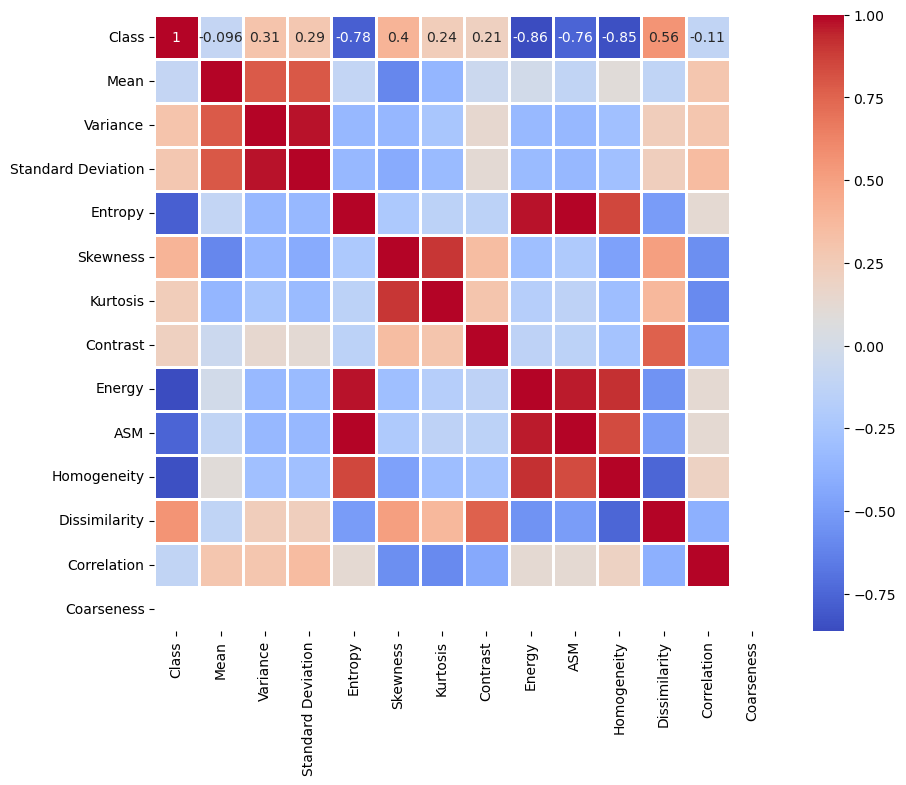

In [14]:
# Heatmap of Correlation matrix of Brain DataFrame
plt.figure(figsize=(10,8))
sns.heatmap(brain_df2.corr(), annot = True, cmap ='coolwarm', linewidths=2)

In [15]:
# drop coarseness column from brain_df2
brain_df3 = brain_df2.drop(['Coarseness'], axis=1)

## Split Dataframe in Train and Test

In [16]:
# drop dependent (Class) column, it will assign to y
X = brain_df3.drop(['Class'], axis = 1)
X.head(6)

,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation
0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939
1,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834
2,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014
3,5.958145,959.711985,30.979219,0.001477,5.677977,33.428845,151.229741,0.032024,0.001026,0.243851,7.700919,0.964189
4,7.315231,729.540579,27.010009,0.146761,4.283221,19.079108,174.988756,0.343849,0.118232,0.501140,6.834689,0.972789
5,7.524109,607.395258,24.645390,0.214086,3.729886,14.471736,105.077882,0.421587,0.177736,0.598169,4.193146,0.976485


In [17]:
# output variable
# assign Class column to y
y = brain_df3['Class']
y.head(6)

0    0
1    0
2    1
3    1
4    0
5    0
Name: Class, dtype: int64

In [18]:
# split dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 5)

In [19]:
X_train

,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation
2021,7.885529,681.803866,26.111374,0.133134,3.806777,14.939540,277.900762,0.326207,0.106411,0.546301,6.445886,0.944215
1286,6.639282,207.782336,14.414657,0.102582,2.607407,7.151179,33.038741,0.282621,0.079875,0.638838,2.064030,0.959070
1106,3.186020,314.159477,17.724544,0.179837,6.354288,43.889536,165.700313,0.383583,0.147136,0.569095,4.329943,0.969997
3688,7.752167,850.780349,29.168139,0.000954,4.667157,23.797444,162.713111,0.025726,0.000662,0.255565,7.630112,0.966914
1781,15.907272,859.296845,29.313765,0.093459,2.257804,5.399814,111.219504,0.269897,0.072845,0.543017,3.945097,0.960212
...,...,...,...,...,...,...,...,...,...,...,...,...
3190,19.755035,1511.266702,38.875014,0.098117,2.359856,5.823204,155.330111,0.276962,0.076708,0.564342,4.108485,0.970138
3046,17.384506,1151.899226,33.939641,0.007915,2.516995,6.645917,119.718675,0.075044,0.005632,0.381815,5.310392,0.944067
1725,9.873734,647.095405,25.438070,0.203971,2.936003,8.936402,116.379595,0.410201,0.168265,0.653499,3.168139,0.965933
2254,4.993439,837.608629,28.941469,0.001184,6.201616,39.682251,98.674332,0.028656,0.000821,0.218662,6.251872,0.960241


In [20]:
X_test

,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation
1829,14.244751,677.906461,26.036637,0.064730,2.245463,5.280704,68.194040,0.221802,0.049196,0.573020,3.171980,0.965574
142,6.439590,711.402252,26.672125,0.003683,4.945783,26.258025,191.833333,0.050998,0.002601,0.252045,8.161609,0.962899
2934,18.273666,960.554970,30.992821,0.053945,2.113554,4.673078,135.033939,0.201307,0.040524,0.550705,3.961433,0.943238
1648,8.556091,557.147920,23.603981,0.187408,3.215624,10.791892,87.087468,0.392090,0.153735,0.626582,3.201900,0.973064
1178,6.661285,761.907895,27.602679,0.004002,4.637791,22.559937,81.489763,0.052887,0.002797,0.370518,4.495690,0.969339
...,...,...,...,...,...,...,...,...,...,...,...,...
3044,2.566971,254.252713,15.945304,0.001956,6.762827,47.224837,43.256424,0.036846,0.001358,0.317558,4.147622,0.983775
2743,11.161804,736.299788,27.134845,0.071535,2.928248,8.891376,147.695042,0.234516,0.054998,0.510246,5.120198,0.954483
3413,7.838409,300.574737,17.337091,0.134217,2.797981,8.655661,51.790533,0.327457,0.107228,0.616866,2.620355,0.960541
1619,4.232285,153.173766,12.376339,0.095976,3.288243,11.029013,35.134788,0.271702,0.073822,0.639419,2.224797,0.956256


In [21]:
y_train

2021    0
1286    0
1106    1
3688    1
1781    0
       ..
3190    0
3046    1
1725    0
2254    1
2915    0
Name: Class, Length: 3009, dtype: int64

In [22]:
y_test

1829    0
142     1
2934    0
1648    0
1178    1
       ..
3044    1
2743    0
3413    0
1619    0
3220    1
Name: Class, Length: 753, dtype: int64

## Feature Scaling

In [23]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

## ML Model Building

In [24]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

## Support Vector Classifier

##### Train with original data 

In [25]:
from sklearn.svm import SVC
svc_classifier = SVC()
svc_classifier.fit(X_train, y_train)
y_pred_svc = svc_classifier.predict(X_test)
accuracy_score(y_test, y_pred_svc)

0.7861885790172642

##### Train with scaled data

In [26]:
svc_classifier2 = SVC()
svc_classifier2.fit(X_train_sc, y_train)
y_pred_svc_sc = svc_classifier2.predict(X_test_sc)
accuracy_score(y_test, y_pred_svc_sc)

0.9774236387782205

## Logistic Regression

##### Train with original data 

In [27]:
from sklearn.linear_model import LogisticRegression
lr_classifier = LogisticRegression(random_state=51, penalty = 'l2')
lr_classifier.fit(X_train, y_train)
y_pred_lr = lr_classifier.predict(X_test)
accuracy_score(y_test, y_pred_lr)

C:\Users\Umair Ali\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9096945551128818

##### Train with scaled data 

In [28]:
lr_classifier2 = LogisticRegression(random_state=51, penalty = 'l2')
lr_classifier2.fit(X_train_sc, y_train)
y_pred_lr_sc = lr_classifier2.predict(X_test_sc)
accuracy_score(y_test, y_pred_lr_sc)

0.9787516600265604

## KNN - K-Nearesr Neighbor Classifier

##### Train with original data

In [29]:
from sklearn.neighbors import KNeighborsClassifier
knn_classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
knn_classifier.fit(X_train, y_train)
y_pred_knn = knn_classifier.predict(X_test)
accuracy_score(y_test, y_pred_knn)

0.8061088977423638

##### Train with scaled data

In [30]:
knn_classifier2 = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
knn_classifier2.fit(X_train_sc, y_train)
y_pred_knn_sc = knn_classifier2.predict(X_test_sc)
accuracy_score(y_test, y_pred_knn_sc)

0.9774236387782205

## Naive Bayes Classifier

##### Train with original data

In [31]:
from sklearn.naive_bayes import GaussianNB
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)
y_pred_nb = nb_classifier.predict(X_test)
accuracy_score(y_test, y_pred_nb)

0.953519256308101

##### Train with scaled data

In [32]:
nb_classifier2 = GaussianNB()
nb_classifier2.fit(X_train_sc, y_train)
y_pred_nb_sc = nb_classifier2.predict(X_test_sc)
accuracy_score(y_test, y_pred_nb_sc)

0.9548472775564409

## Decision Tree Classifier

##### Train with original data

In [33]:
from sklearn.tree import DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 51)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
accuracy_score(y_test, y_pred_dt)

0.9814077025232404

##### Train with scaled data

In [34]:
dt_classifier2 = DecisionTreeClassifier(criterion = 'entropy', random_state = 51)
dt_classifier2.fit(X_train_sc, y_train)
y_pred_dt_sc = dt_classifier2.predict(X_test_sc)
accuracy_score(y_test, y_pred_dt_sc)

0.9814077025232404

## Random Forest Classifier

##### Train with original data

In [35]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators = 20, criterion = 'entropy', random_state = 51)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)
accuracy_score(y_test, y_pred_rf)

0.9827357237715804

##### Train with scaled data

In [36]:
rf_classifier2 = RandomForestClassifier(n_estimators = 20, criterion = 'entropy', random_state = 51)
rf_classifier2.fit(X_train_sc, y_train)
y_pred_rf_sc = rf_classifier2.predict(X_test_sc)
accuracy_score(y_test, y_pred_rf_sc)

0.9827357237715804

## Confusion Matrix

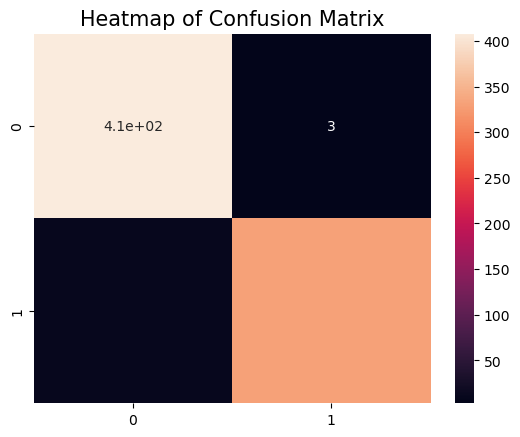

In [37]:
cm = confusion_matrix(y_test, y_pred_rf_sc)
plt.title('Heatmap of Confusion Matrix', fontsize = 15)
sns.heatmap(cm, annot = True)
plt.show()

## Classification Report Of model

In [38]:
print(classification_report(y_test, y_pred_rf_sc))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       411
           1       0.99      0.97      0.98       342

    accuracy                           0.98       753
   macro avg       0.98      0.98      0.98       753
weighted avg       0.98      0.98      0.98       753



## Cross-validation of the ML model

In [39]:
# Cross validation
from sklearn.model_selection import cross_val_score
cross_validation = cross_val_score(estimator = rf_classifier2, X = X_train_sc,y = y_train, cv = 10)
print("Cross validation accuracy of SVC model = ", cross_validation)
print("\nCross validation mean accuracy of SVC model = ", cross_validation.mean())

Cross validation accuracy of SVC model =  [0.98671096 0.99335548 0.99003322 0.97009967 0.9833887  0.97674419
 0.99335548 0.99003322 0.99335548 0.99666667]

Cross validation mean accuracy of SVC model =  0.9873743078626799


## Test Model

In [45]:
# we have one patient data
patient1 = [17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,
            0.1471,0.2419,0.07871,1.095,0.9053]

In [41]:
# convert list into array and scale
patient1_sc = sc.transform(np.array([patient1]))
patient1_sc

C:\Users\Umair Ali\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 1.49256979e+00, -1.49381108e+00,  1.11029758e+01,
         1.40960224e+04, -1.54791906e+00, -4.16334494e-01,
        -1.13805522e+00, -4.48064734e-01,  3.09915646e+00,
        -3.10934480e+00, -1.93429813e+00, -1.84574993e+00]])

In [42]:
# predict patient1_sc scale data
# zero mean malignant patient has cancer
predict = rf_classifier2.predict(patient1_sc)
predict

array([0], dtype=int64)

In [43]:
# write if else statement to print result in clear format
if predict[0] == 0:
    print ('Patient has *** NO *** Tumor / Cancer')
else:
    print ('Patient *** HAS *** Tumor / Cancer')

Patient has *** NO *** Tumor / Cancer


In [44]:
# confusion matrix
print('Confusion matrix of Random Forest model: \n',confusion_matrix(y_test, y_pred_rf_sc),'\n')

# show the accuracy
print('Accuracy of Random Forest model = ',accuracy_score(y_test, y_pred_rf_sc))

Confusion matrix of Random Forest model: 
 [[408   3]
 [ 10 332]] 

Accuracy of Random Forest model =  0.9827357237715804
